# Setup: Generación de Datos e Imágenes Sintéticas

En las siguientes secciones se generarán de forma automática:

- **Datos sintéticos CSV**: Se crean archivos para entrenamiento y validación que se utilizarán en los ejercicios de regresión y clasificación.
- **Imágenes sintéticas**: Se generan una imagen en escala de grises (`face.png`) y una imagen en color (`cat.jpg`), que se utilizarán para los ejercicios de visión artificial.

Además, se generarán archivos en formato IDX para simular un conjunto de datos tipo MNIST, de forma que el ejercicio 7 pueda ejecutarse sin archivos externos.

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image

# Crear directorios necesarios
if not os.path.exists('datasets'):
    os.makedirs('datasets')
if not os.path.exists('datasets/ds_cv_images'):
    os.makedirs('datasets/ds_cv_images')

## Generar datos sintéticos para CSV
# Parámetros: 200 muestras de entrenamiento y 100 de prueba, 5 características
n_train = 200
n_test = 100
n_features = 5
np.random.seed(42)

In [2]:
# Datos de entrenamiento
X_train = np.random.randn(n_train, n_features)
coefficients = np.random.randn(n_features)
y_train = X_train.dot(coefficients) + np.random.randn(n_train) * 0.5

In [3]:
# Datos de validación
X_test = np.random.randn(n_test, n_features)
y_test = X_test.dot(coefficients) + np.random.randn(n_test) * 0.5

In [4]:
# Crear DataFrames y guardar en CSV
train_df = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(n_features)])
train_df['target'] = y_train

test_df = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(n_features)])
test_df['target'] = y_test

train_csv_path = 'datasets/train_data_n.csv'
test_csv_path = 'datasets/test_data_n.csv'
train_df.to_csv(train_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print('CSV generados en:', train_csv_path, 'y', test_csv_path)

CSV generados en: datasets/train_data_n.csv y datasets/test_data_n.csv


In [5]:
## Generar imágenes sintéticas
width, height = 256, 256

# Imagen en escala de grises: gradiente horizontal
gradient = np.tile(np.linspace(0, 255, width, dtype=np.uint8), (height, 1))
face_image = Image.fromarray(gradient)
face_path = 'datasets/ds_cv_images/face.png'
face_image.save(face_path)
print('Imagen en escala de grises generada en', face_path)

# Imagen en color: bandas de colores
color_image_array = np.zeros((height, width, 3), dtype=np.uint8)
color_image_array[..., 0] = np.tile(np.linspace(0, 255, width, dtype=np.uint8), (height, 1))  # Canal rojo
color_image_array[..., 1] = np.tile(np.linspace(255, 0, width, dtype=np.uint8), (height, 1))  # Canal verde
color_image_array[..., 2] = 128  # Canal azul constante
cat_image = Image.fromarray(color_image_array)
cat_path = 'datasets/ds_cv_images/cat.jpg'
cat_image.save(cat_path)
print('Imagen en color generada en', cat_path)

Imagen en escala de grises generada en datasets/ds_cv_images/face.png
Imagen en color generada en datasets/ds_cv_images/cat.jpg


In [8]:
import os
import struct
import numpy as np

# Crear directorio para archivos IDX (si no existe)
if not os.path.exists('dataset'):
    os.makedirs('dataset')

## Generar archivos IDX sintéticos para MNIST
# Usaremos un número reducido de imágenes para fines de demostración (por ejemplo, 1000 imágenes de 28x28)
num_images = 1000
rows, cols = 28, 28

# Generar imágenes sintéticas: valores aleatorios entre 0 y 255
images = np.random.randint(0, 256, size=(num_images, rows, cols), dtype=np.uint8)

# Generar etiquetas sintéticas: enteros aleatorios entre 0 y 9
labels = np.random.randint(0, 10, size=(num_images,), dtype=np.uint8)

# Escribir archivo de imágenes (formato IDX)
with open('dataset/train-images.idx3-ubyte', 'wb') as f:
    # Encabezado: 2 bytes cero, 1 byte (tipo de dato: 8), 1 byte (dimensiones: 3)
    f.write(struct.pack('>HBB', 0, 8, 3))
    # Escribir dimensiones: número de imágenes, filas, columnas
    f.write(struct.pack('>III', num_images, rows, cols))
    # Escribir los datos de las imágenes
    f.write(images.tobytes())

# Escribir archivo de etiquetas (formato IDX)
with open('dataset/train-labels.idx1-ubyte', 'wb') as f:
    # Encabezado: 2 bytes cero, 1 byte (tipo de dato: 8), 1 byte (dimensiones: 1)
    f.write(struct.pack('>HBB', 0, 8, 1))
    # Escribir la dimensión: número de etiquetas
    f.write(struct.pack('>I', num_images))
    # Escribir los datos de las etiquetas
    f.write(labels.tobytes())

print("Archivos IDX generados en el directorio 'dataset'.")

Archivos IDX generados en el directorio 'dataset'.


In [7]:
import os
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

# Crear directorios necesarios
if not os.path.exists('datasets'):
    os.makedirs('datasets')
if not os.path.exists('datasets/ds_cv_images'):
    os.makedirs('datasets/ds_cv_images')

##########################################
# Generar datos sintéticos para CSV (igual que antes)
##########################################
n_train = 200
n_test = 100
n_features = 5
np.random.seed(42)

# Datos de entrenamiento
X_train = np.random.randn(n_train, n_features)
coefficients = np.random.randn(n_features)
y_train = X_train.dot(coefficients) + np.random.randn(n_train) * 0.5

# Datos de validación
X_test = np.random.randn(n_test, n_features)
y_test = X_test.dot(coefficients) + np.random.randn(n_test) * 0.5

# Crear DataFrames y guardar en CSV
train_df = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(n_features)])
train_df['target'] = y_train

test_df = pd.DataFrame(X_test, columns=[f'feature_{i}' for i in range(n_features)])
test_df['target'] = y_test

train_csv_path = 'datasets/train_data_n.csv'
test_csv_path = 'datasets/test_data_n.csv'
train_df.to_csv(train_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print('CSV generados en:', train_csv_path, 'y', test_csv_path)

##########################################
# Generar imagen en escala de grises (face.png)
##########################################
width, height = 256, 256
face_img = Image.new('L', (width, height), color=200)  # L = modo de escala de grises
draw_face = ImageDraw.Draw(face_img)

# Dibuja un óvalo grande (cabeza)
draw_face.ellipse((50, 30, 206, 186), fill=230, outline=255)

# Ojos (óvalos negros)
draw_face.ellipse((90, 70, 110, 90), fill=0)   # ojo izquierdo
draw_face.ellipse((146, 70, 166, 90), fill=0)  # ojo derecho

# Nariz (pequeño óvalo)
draw_face.ellipse((120, 90, 136, 105), fill=40)

# Boca (arco)
draw_face.arc((90, 100, 166, 150), start=180, end=360, fill=0)

face_path = 'datasets/ds_cv_images/face.png'
face_img.save(face_path)
print('Imagen en escala de grises generada en', face_path)

##########################################
# Generar imagen en color (cat.jpg)
##########################################
cat_img = Image.new('RGB', (width, height), color=(255, 255, 255))  # Fondo blanco
draw_cat = ImageDraw.Draw(cat_img)

# Silueta de gato (cabeza grande tipo círculo)
draw_cat.ellipse((50, 50, 206, 206), fill=(50, 50, 50))  # Gato gris oscuro

# Orejas (triángulos)
draw_cat.polygon([(70, 40), (90, 60), (50, 70)], fill=(50, 50, 50))   # Oreja izq
draw_cat.polygon([(186, 40), (166, 60), (206, 70)], fill=(50, 50, 50)) # Oreja der

# Ojos (óvalos blancos)
draw_cat.ellipse((90, 100, 110, 120), fill=(255, 255, 255))
draw_cat.ellipse((146, 100, 166, 120), fill=(255, 255, 255))

# Nariz (pequeño óvalo rosado)
draw_cat.ellipse((125, 120, 131, 126), fill=(255, 192, 203))

# Bigotes (líneas)
draw_cat.line((130, 123, 160, 123), fill=(255, 192, 203), width=2)
draw_cat.line((126, 125, 100, 140), fill=(255, 192, 203), width=2)

cat_path = 'datasets/ds_cv_images/cat.jpg'
cat_img.save(cat_path)
print('Imagen en color generada en', cat_path)


CSV generados en: datasets/train_data_n.csv y datasets/test_data_n.csv
Imagen en escala de grises generada en datasets/ds_cv_images/face.png
Imagen en color generada en datasets/ds_cv_images/cat.jpg


# Ejercicio 1: Regresión Lineal con Keras

**Introducción:** En este ejercicio se implementa una red neuronal de una sola neurona utilizando Keras, lo que equivale a un modelo de regresión lineal.

**Objetivo:** Entrenar un modelo de regresión lineal con datos de entrenamiento y validación, utilizando el error cuadrático medio como función de pérdida.

**Explicación:** Se cargan los datos desde los archivos CSV generados, se separan las características y la variable objetivo, se define un modelo secuencial simple y se entrena utilizando el optimizador SGD.

In [9]:
import pandas as pd
from tensorflow import keras

# Cargar datos de entrenamiento y validación
data_train = pd.read_csv('datasets/train_data_n.csv')
features_train = data_train.drop('target', axis=1)
target_train = data_train['target']

data_valid = pd.read_csv('datasets/test_data_n.csv')
features_valid = data_valid.drop('target', axis=1)
target_valid = data_valid['target']




In [10]:
# Crear modelo de regresión lineal (una sola neurona)
model = keras.models.Sequential()
model.add(keras.layers.Dense(units=1, input_dim=features_train.shape[1]))

C:\Users\ljpca\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compilar el modelo
model.compile(loss='mean_squared_error', optimizer='sgd')

In [12]:
# Entrenar el modelo
model.fit(
    features_train,
    target_train,
    verbose=2,
    epochs=5,
    validation_data=(features_valid, target_valid)
)

Epoch 1/5
7/7 - 1s - 83ms/step - loss: 6.5405 - val_loss: 6.4468
Epoch 2/5
7/7 - 0s - 20ms/step - loss: 5.1225 - val_loss: 5.0168
Epoch 3/5
7/7 - 0s - 19ms/step - loss: 3.9729 - val_loss: 3.9639
Epoch 4/5
7/7 - 0s - 20ms/step - loss: 3.1145 - val_loss: 3.1567
Epoch 5/5
7/7 - 0s - 21ms/step - loss: 2.4660 - val_loss: 2.4966


# Ejercicio 2: Regresión Logística con Keras

**Introducción:** Se adapta el ejercicio anterior para la clasificación binaria, utilizando una sola neurona con función de activación sigmoide, lo que equivale a la regresión logística.

**Objetivo:** Convertir el problema en uno de clasificación binaria, utilizando la entropía cruzada como función de pérdida.

**Explicación:** Se transforma la variable objetivo en valores binarios y se define un modelo con activación `sigmoid`. Luego se compila el modelo con `binary_crossentropy` y se entrena.

In [5]:
import pandas as pd
from tensorflow import keras
from sklearn.metrics import accuracy_score

# Cargar y transformar los datos para clasificación binaria
df = pd.read_csv('datasets/train_data_n.csv')
df['target'] = (df['target'] > df['target'].median()).astype(int)
features_train = df.drop('target', axis=1)
target_train = df['target']

df_val = pd.read_csv('datasets/test_data_n.csv')
df_val['target'] = (df_val['target'] > df['target'].median()).astype(int)
features_valid = df_val.drop('target', axis=1)
target_valid = df_val['target']

# Crear modelo de regresión logística (una neurona con activación sigmoide)
model = keras.models.Sequential()
model.add(
    keras.layers.Dense(
        units=1, input_dim=features_train.shape[1], activation='sigmoid'
    )
)

# Compilar el modelo
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['acc'])

# Entrenar el modelo
model.fit(
    features_train,
    target_train,
    epochs=10,
    verbose=2,
    validation_data=(features_valid, target_valid)
)


Epoch 1/10


C:\Users\ljpca\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 - 1s - 112ms/step - acc: 0.5500 - loss: 0.8301 - val_acc: 0.5500 - val_loss: 0.7515
Epoch 2/10
7/7 - 0s - 18ms/step - acc: 0.5600 - loss: 0.8161 - val_acc: 0.5800 - val_loss: 0.7381
Epoch 3/10
7/7 - 0s - 19ms/step - acc: 0.5650 - loss: 0.8013 - val_acc: 0.5800 - val_loss: 0.7248
Epoch 4/10
7/7 - 0s - 17ms/step - acc: 0.5750 - loss: 0.7870 - val_acc: 0.5800 - val_loss: 0.7113
Epoch 5/10
7/7 - 0s - 16ms/step - acc: 0.5850 - loss: 0.7726 - val_acc: 0.5800 - val_loss: 0.6997
Epoch 6/10
7/7 - 0s - 17ms/step - acc: 0.5850 - loss: 0.7599 - val_acc: 0.5800 - val_loss: 0.6876
Epoch 7/10
7/7 - 0s - 16ms/step - acc: 0.5950 - loss: 0.7466 - val_acc: 0.5800 - val_loss: 0.6766
Epoch 8/10
7/7 - 0s - 18ms/step - acc: 0.6000 - loss: 0.7343 - val_acc: 0.5900 - val_loss: 0.6649
Epoch 9/10
7/7 - 0s - 18ms/step - acc: 0.6000 - loss: 0.7209 - val_acc: 0.6100 - val_loss: 0.6538
Epoch 10/10
7/7 - 0s - 17ms/step - acc: 0.6050 - loss: 0.7090 - val_acc: 0.6100 - val_loss: 0.6439


# Ejercicio 3: Redes Neuronales Totalmente Conectadas

**Introducción:** Se profundiza en el uso de redes neuronales totalmente conectadas añadiendo capas y neuronas adicionales para mejorar la capacidad de aprendizaje del modelo.

**Objetivo:** Implementar un modelo con al menos una capa oculta y comparar su rendimiento con modelos más simples.

**Explicación:** Se crea un modelo con una capa oculta de 10 neuronas y una capa de salida con activación sigmoide, utilizando datos de clasificación binaria.

**Pregunta:** ¿Cómo cambia una red neuronal cuando agregamos más neuronas y capas?
- **Respuesta:** Aumentar el número de neuronas y capas permite que el modelo aprenda patrones más complejos y representaciones no lineales, aunque incrementa el riesgo de sobreajuste si no se controla adecuadamente.

In [6]:
import pandas as pd
from tensorflow import keras

# Cargar y transformar datos para clasificación binaria
df = pd.read_csv('datasets/train_data_n.csv')
df['target'] = (df['target'] > df['target'].median()).astype(int)
features_train = df.drop('target', axis=1)
target_train = df['target']

df_val = pd.read_csv('datasets/test_data_n.csv')
df_val['target'] = (df_val['target'] > df['target'].median()).astype(int)
features_valid = df_val.drop('target', axis=1)
target_valid = df_val['target']

# Modelo con una capa oculta de 10 neuronas
model = keras.models.Sequential()
model.add(
    keras.layers.Dense(
        units=10, input_dim=features_train.shape[1], activation='sigmoid'
    )
)
model.add(keras.layers.Dense(units=1, activation='sigmoid'))

# Compilar y entrenar el modelo
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['acc'])
model.fit(
    features_train,
    target_train,
    epochs=10,
    verbose=2,
    validation_data=(features_valid, target_valid)
)


Epoch 1/10


C:\Users\ljpca\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 - 1s - 115ms/step - acc: 0.5000 - loss: 0.9430 - val_acc: 0.4800 - val_loss: 0.9543
Epoch 2/10
7/7 - 0s - 16ms/step - acc: 0.5000 - loss: 0.9208 - val_acc: 0.4800 - val_loss: 0.9269
Epoch 3/10
7/7 - 0s - 18ms/step - acc: 0.5000 - loss: 0.8955 - val_acc: 0.4800 - val_loss: 0.9029
Epoch 4/10
7/7 - 0s - 19ms/step - acc: 0.5000 - loss: 0.8735 - val_acc: 0.4800 - val_loss: 0.8819
Epoch 5/10
7/7 - 0s - 18ms/step - acc: 0.5000 - loss: 0.8543 - val_acc: 0.4800 - val_loss: 0.8638
Epoch 6/10
7/7 - 0s - 19ms/step - acc: 0.5000 - loss: 0.8377 - val_acc: 0.4800 - val_loss: 0.8472
Epoch 7/10
7/7 - 0s - 20ms/step - acc: 0.5000 - loss: 0.8225 - val_acc: 0.4800 - val_loss: 0.8313
Epoch 8/10
7/7 - 0s - 19ms/step - acc: 0.5000 - loss: 0.8082 - val_acc: 0.4800 - val_loss: 0.8158
Epoch 9/10
7/7 - 0s - 19ms/step - acc: 0.5000 - loss: 0.7940 - val_acc: 0.4800 - val_loss: 0.7994
Epoch 10/10
7/7 - 0s - 18ms/step - acc: 0.5000 - loss: 0.7793 - val_acc: 0.4800 - val_loss: 0.7857


# Ejercicio 4: Trabajar con Imágenes en Python (Escala de Grises)

**Introducción:** Se carga y preprocesa una imagen en escala de grises, normalizando sus valores entre 0 y 1.

**Objetivo:** Convertir una imagen a un array de NumPy, normalizar sus valores y visualizarla utilizando Matplotlib.

**Explicación:** Se utiliza la librería PIL para abrir la imagen, se transforma a array, se normaliza dividiendo entre 255 y se muestra la imagen.

In [13]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Cargar la imagen
image = Image.open('datasets/ds_cv_images/face.png')
array = np.array(image)

In [16]:
array

array([[0.78431373, 0.78431373, 0.78431373, ..., 0.78431373, 0.78431373,
        0.78431373],
       [0.78431373, 0.78431373, 0.78431373, ..., 0.78431373, 0.78431373,
        0.78431373],
       [0.78431373, 0.78431373, 0.78431373, ..., 0.78431373, 0.78431373,
        0.78431373],
       ...,
       [0.78431373, 0.78431373, 0.78431373, ..., 0.78431373, 0.78431373,
        0.78431373],
       [0.78431373, 0.78431373, 0.78431373, ..., 0.78431373, 0.78431373,
        0.78431373],
       [0.78431373, 0.78431373, 0.78431373, ..., 0.78431373, 0.78431373,
        0.78431373]])

In [17]:
# Normalizar la imagen
array = array / 255.0

In [18]:
array

array([[0.00307574, 0.00307574, 0.00307574, ..., 0.00307574, 0.00307574,
        0.00307574],
       [0.00307574, 0.00307574, 0.00307574, ..., 0.00307574, 0.00307574,
        0.00307574],
       [0.00307574, 0.00307574, 0.00307574, ..., 0.00307574, 0.00307574,
        0.00307574],
       ...,
       [0.00307574, 0.00307574, 0.00307574, ..., 0.00307574, 0.00307574,
        0.00307574],
       [0.00307574, 0.00307574, 0.00307574, ..., 0.00307574, 0.00307574,
        0.00307574],
       [0.00307574, 0.00307574, 0.00307574, ..., 0.00307574, 0.00307574,
        0.00307574]])

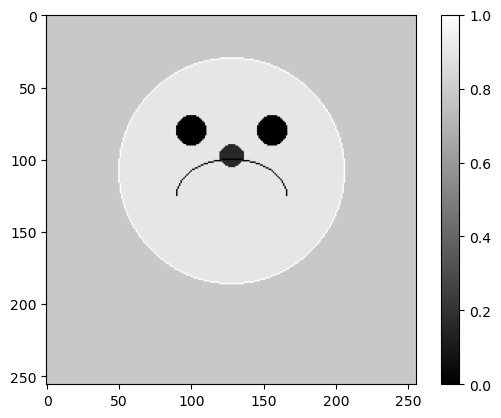

In [15]:
# Visualizar la imagen en escala de grises
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.show()

# Ejercicio 5: Trabajar con Imágenes en Color

**Introducción:** Se extrae y visualiza el canal rojo de una imagen en color, demostrando cómo acceder a los distintos canales de una imagen.

**Objetivo:** Cargar una imagen en color y visualizar únicamente su canal rojo.

**Explicación:** La imagen se carga con PIL y se convierte a un array. Luego se extrae el primer canal (rojo) y se visualiza mediante Matplotlib.

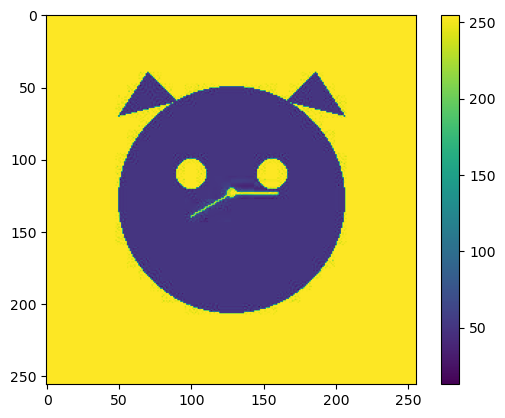

In [19]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen en color
image = Image.open('datasets/ds_cv_images/cat.jpg')
array = np.array(image)

# Extraer el canal rojo
red_channel = array[:, :, 0]

# Visualizar el canal rojo
plt.imshow(red_channel)
plt.colorbar()
plt.show()


# Ejercicio 6: Clasificación Multiclase con Fashion MNIST

**Introducción:** Se implementa una red neuronal para la clasificación de imágenes del conjunto de datos Fashion MNIST utilizando una capa de salida con activación softmax.

**Objetivo:** Convertir cada imagen en un vector, entrenar un modelo de clasificación multiclase y evaluar su desempeño.

**Explicación:** Se carga el conjunto de datos Fashion MNIST, se remodelan las imágenes y se define un modelo secuencial con una capa de salida de 10 neuronas.

In [9]:
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Cargar el conjunto de datos Fashion MNIST
(features_train, target_train), (features_test, target_test) = keras.datasets.fashion_mnist.load_data()

# Remodelar las imágenes para convertirlas en vectores
features_train = features_train.reshape(features_train.shape[0], 28 * 28)
features_test = features_test.reshape(features_test.shape[0], 28 * 28)

# Crear el modelo de clasificación multiclase
model = keras.models.Sequential()
model.add(
    keras.layers.Dense(units=10, input_dim=28 * 28, activation='softmax')
)

# Compilar y entrenar el modelo
model.compile(
    loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['acc']
)

model.fit(
    features_train,
    target_train,
    epochs=1,
    verbose=2,
    validation_data=(features_test, target_test)
)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


C:\Users\ljpca\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 - 4s - 2ms/step - acc: 0.7390 - loss: 2032.8809 - val_acc: 0.7880 - val_loss: 2104.2073


# Ejercicio 7: Entrenamiento de Red Multicapa con MNIST

**Introducción:** En este ejercicio se construye y entrena una red neuronal multicapa para clasificar imágenes del conjunto de datos MNIST. Se implementan tres funciones:

1. **load_data()**: Carga y preprocesa los datos a partir de archivos en formato IDX.
2. **create_model()**: Define y compila la arquitectura del modelo.
3. **train_model()**: Entrena el modelo utilizando los datos de entrenamiento y validación.

**Objetivo:** Comprender el flujo completo de carga, creación y entrenamiento de una red neuronal multicapa.

**Explicación:** Se leen archivos en formato IDX para cargar el conjunto de datos, se normalizan las imágenes y se divide el dataset en entrenamiento y prueba. Luego se define una arquitectura de red con varias capas y se entrena el modelo.

In [10]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def read_idx(filename):
    """Lee un archivo en formato IDX y retorna un array de NumPy."""
    with open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

def load_data(img_path, lbl_path):
    """Carga y preprocesa los datos a partir de archivos IDX."""
    X = read_idx(img_path)
    y = read_idx(lbl_path)
    
    X = X.astype('float32')
    X /= 255.0
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
    return X_train, y_train, X_test, y_test

def create_model(input_shape, num_classes):
    """Crea y compila un modelo de red neuronal multicapa."""
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Capa de salida
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])
    
    return model
    
def train_model(model, train_data, test_data, batch_size=32, epochs=5):
    """Entrena el modelo con los datos proporcionados."""
    history = model.fit(train_data[0], train_data[1],
                        validation_data=test_data,
                        batch_size=batch_size, 
                        epochs=epochs,
                        shuffle=True,
                        verbose=2)
    return history

# Rutas de los archivos IDX generados
img_path = 'dataset/train-images.idx3-ubyte'
lbl_path = 'dataset/train-labels.idx1-ubyte'

X_train, y_train, X_test, y_test = load_data(img_path, lbl_path)

model = create_model((28, 28), 10)
model_trained = train_model(model, (X_train, y_train), (X_test, y_test), batch_size=32, epochs=10)


Epoch 1/10


C:\Users\ljpca\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 - 2s - 75ms/step - acc: 0.1013 - loss: 2.3346 - val_acc: 0.1300 - val_loss: 2.2968
Epoch 2/10
25/25 - 0s - 8ms/step - acc: 0.1088 - loss: 2.3013 - val_acc: 0.1250 - val_loss: 2.3020
Epoch 3/10
25/25 - 0s - 6ms/step - acc: 0.1112 - loss: 2.3023 - val_acc: 0.0650 - val_loss: 2.3011
Epoch 4/10
25/25 - 0s - 7ms/step - acc: 0.1125 - loss: 2.3004 - val_acc: 0.1050 - val_loss: 2.3057
Epoch 5/10
25/25 - 0s - 7ms/step - acc: 0.1262 - loss: 2.3009 - val_acc: 0.0750 - val_loss: 2.3010
Epoch 6/10
25/25 - 0s - 7ms/step - acc: 0.1587 - loss: 2.2974 - val_acc: 0.0750 - val_loss: 2.3010
Epoch 7/10
25/25 - 0s - 6ms/step - acc: 0.1163 - loss: 2.2985 - val_acc: 0.0700 - val_loss: 2.2996
Epoch 8/10
25/25 - 0s - 7ms/step - acc: 0.1238 - loss: 2.2957 - val_acc: 0.0700 - val_loss: 2.3000
Epoch 9/10
25/25 - 0s - 7ms/step - acc: 0.1150 - loss: 2.2976 - val_acc: 0.1250 - val_loss: 2.2970
Epoch 10/10
25/25 - 0s - 7ms/step - acc: 0.1150 - loss: 2.2977 - val_acc: 0.0700 - val_loss: 2.2997


# Ejercicio 8: Visualización de Funciones de Activación

**Introducción:** Se grafican distintas funciones de activación (sigmoide, tanh y ReLU) para observar sus comportamientos y diferencias.

**Objetivo:** Visualizar y comparar las curvas de las funciones de activación más comunes utilizadas en redes neuronales.

**Explicación:** Se define un rango de valores y se aplican las funciones de activación para graficarlas con Matplotlib.

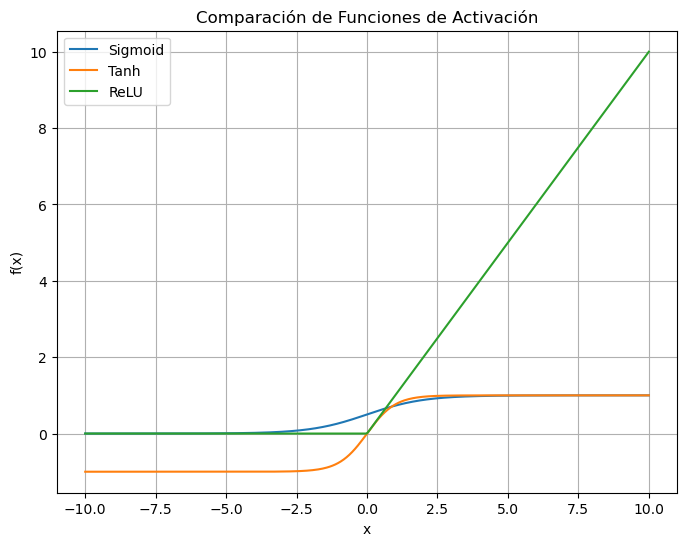

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Definir funciones de activación
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

# Rango de valores para x
x = np.linspace(-10, 10, 400)

# Calcular salidas de cada función
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

# Graficar las funciones
plt.figure(figsize=(8, 6))
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.title('Comparación de Funciones de Activación')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()


# Ejercicio 9: Ajuste de Hiperparámetros

**Introducción:** Se investiga cómo diferentes configuraciones de hiperparámetros, como la tasa de aprendizaje y el número de épocas, afectan el proceso de entrenamiento de un modelo simple.

**Objetivo:** Experimentar con distintos valores de hiperparámetros y visualizar su impacto en la convergencia del modelo.

**Explicación:** Se genera un conjunto de datos sintético para un problema de regresión, se entrena un modelo simple variando la tasa de aprendizaje y se comparan las curvas de pérdida resultantes.

C:\Users\ljpca\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando con tasa de aprendizaje: 0.001
Entrenando con tasa de aprendizaje: 0.01
Entrenando con tasa de aprendizaje: 0.1


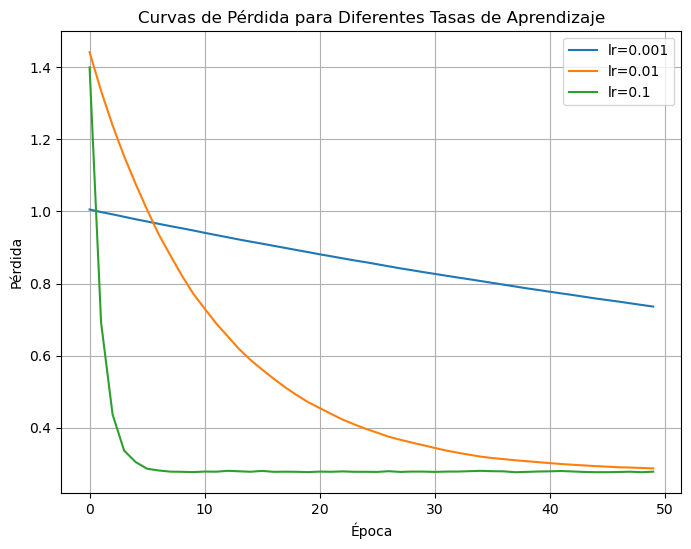

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# Generar datos sintéticos para regresión
np.random.seed(123)
X = np.linspace(-1, 1, 200)
y = 3 * X + np.random.randn(200) * 0.5  # Relación lineal con ruido

# Remodelar los datos
X = X.reshape(-1, 1)

learning_rates = [0.001, 0.01, 0.1]
histories = {}

for lr in learning_rates:
    model = Sequential()
    model.add(Dense(units=1, input_dim=1))
    model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=lr))
    print(f"Entrenando con tasa de aprendizaje: {lr}")
    history = model.fit(X, y, epochs=50, verbose=0)
    histories[lr] = history.history['loss']

# Graficar las curvas de pérdida para cada tasa de aprendizaje
plt.figure(figsize=(8,6))
for lr, loss in histories.items():
    plt.plot(loss, label=f'lr={lr}')
plt.title('Curvas de Pérdida para Diferentes Tasas de Aprendizaje')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()


In [1]:
!pip install pandoc


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
